In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from matplotlib.colors import ListedColormap


In [3]:
# Load dataset
dataset = pd.read_csv('Social_Network_Ads.csv')

# Select features and label
X = dataset.iloc[:, 2:4].values  # Age and Estimated Salary
y = dataset.iloc[:, 4].values    # Purchased (0 or 1)

In [4]:
# Feature Scaling (Important for Logistic Regression to converge properly)
sc = StandardScaler()
X = sc.fit_transform(X)

In [6]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=0)
# Train the Logistic Regression model
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [9]:
# Predict on test set
y_pred = classifier.predict(X_test)

=== Evaluation Metrics ===
Accuracy Score   : 89.00%
Precision Score  : 88.89%
Recall Score     : 75.00%
F1 Score         : 81.36%


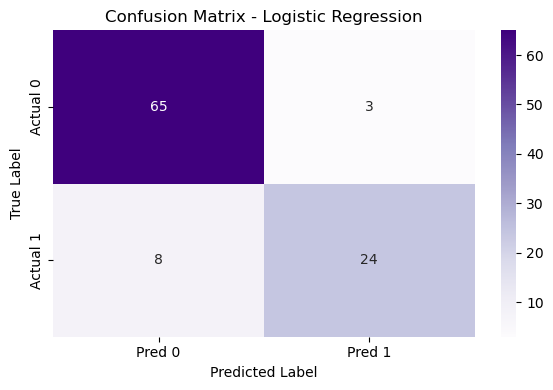

In [10]:

# Confusion Matrix and Metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display metrics
print("=== Evaluation Metrics ===")
print(f"Accuracy Score   : {acc * 100:.2f}%")
print(f"Precision Score  : {prec * 100:.2f}%")
print(f"Recall Score     : {rec * 100:.2f}%")
print(f"F1 Score         : {f1 * 100:.2f}%")

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()